## **SNAP Jupyter demo notebook**
**SAR + optical collocation — fuse Sentinel-1 backscatter with Sentinel-2 spectral indices**

In summary, this workflow contains:

- Background on why combining SAR and optical helps
- Preprocess a Sentinel-1 GRD scene to terrain-corrected sigma₀ (VV, VH)
- Preprocess a Sentinel-2 L2A scene: resample to 10 m, compute NDVI and NDWI
- **Collocate** the S1 product onto the S2 grid
- Compute a joint feature (RGB composite of NDVI + sigma₀_VH + sigma₀_VV) and a simple wetland/crop application

Complexity: advanced

##### ***About the test data:***

A coincident **Sentinel-1 GRD** + **Sentinel-2 L2A** pair over the **Sacramento–San Joaquin Delta** (both 2023-08-27, ~0% cloud), each subset to a ~12×12 km AOI, **auto-downloads from public S3** on first run and is cached in `data/` — no account needed.

To use your own scene instead: one `S1*_IW_GRDH_1S*` and one `S2*_MSIL2A_*` over the same area on close dates (both free from the [Copernicus Browser](https://dataspace.copernicus.eu/browser/)); point the `fetch_dimap_zip(...)` calls in the config cell at them. A mix of vegetation, water and bare ground gives the most interesting fused result.

##### ***Some information on the Python environment:***

In [1]:
import os
import sys
print("Python version: " + sys.version)

import sysconfig
print("Location of esa_snappy package: " + sysconfig.get_paths()['purelib'] + os.sep + "esa_snappy")

Python version: 3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]
Location of esa_snappy package: C:\Users\luis_\AppData\Local\Programs\Python\Python313\Lib\site-packages\esa_snappy


##### ***Import Python packages...***

In [2]:
import esa_snappy
from esa_snappy import ProductIO

import snapista
from snapista import Graph
from snapista import Operator
from snapista import TargetBand
from snapista import TargetBandDescriptors

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

##### ***Convenience plot functions:***

In [3]:
def _read_band(product, name):
    band = product.getBand(name)
    if band is None:
        raise KeyError(f"Band {name!r} not found. Available: {[b.getName() for b in product.getBands()]}")
    w, h = band.getRasterWidth(), band.getRasterHeight()
    data = np.zeros(w * h, np.float32)
    band.readPixels(0, 0, w, h, data)
    data.shape = h, w
    return data

def plot_band(product, name, title=None, cmap='viridis', vmin=None, vmax=None):
    data = _read_band(product, name)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title or name)
    fig.colorbar(im, ax=ax)
    plt.show()

def plot_interferogram(product, phase_band_name, coh_band_name=None):
    phi = _read_band(product, phase_band_name)
    if coh_band_name is None:
        fig, ax = plt.subplots(figsize=(7, 6))
        im = ax.imshow(phi, cmap='hsv', vmin=-np.pi, vmax=np.pi)
        ax.set_title('Wrapped interferogram phase [rad]')
        fig.colorbar(im, ax=ax)
    else:
        coh = _read_band(product, coh_band_name)
        fig, axs = plt.subplots(1, 2, figsize=(13, 5))
        im0 = axs[0].imshow(phi, cmap='hsv', vmin=-np.pi, vmax=np.pi)
        axs[0].set_title('Wrapped phase [rad]')
        fig.colorbar(im0, ax=axs[0])
        im1 = axs[1].imshow(coh, cmap='viridis', vmin=0, vmax=1)
        axs[1].set_title('Coherence')
        fig.colorbar(im1, ax=axs[1])
    plt.show()

def find_band(product, *patterns):
    names = [b.getName() for b in product.getBands()]
    for pat in patterns:
        for n in names:
            if pat.lower() in n.lower():
                return n
    raise KeyError(f"No band matching {patterns!r} found. Available: {names}")

---

### ***Background: why combine SAR and optical?***

The two sensor types see different physical properties of the surface and have complementary failure modes:

| Property | Sentinel-1 (SAR) | Sentinel-2 (optical) |
|:---------|:-----------------|:---------------------|
| Day/night | yes | day only |
| Cloud cover | sees through | blocked |
| Sensitive to | dielectric, roughness, structure | chlorophyll, water, soil colour |
| Typical issues | speckle, geometric distortion, layover | clouds, shadows, atmospheric haze |
| Volume scattering | strong over canopy | weak |
| Vegetation greenness | weak | strong (NDVI) |
| Surface roughness | strong | weak |

Joint analysis works because the *combined* feature space discriminates classes that neither sensor can separate alone. Two canonical examples:

- **Flooded vegetation**: water under canopy is invisible to S2 (canopy blocks the view) but shows up as a strong double-bounce return in S1.
- **Crop type classification**: NDVI tracks chlorophyll; sigma₀_VH tracks biomass. Two crops with similar NDVI but different structure (e.g. wheat vs rapeseed) separate cleanly on the S1 axis.

The SNAP operator `Collocate` resamples one product onto another's geocoded grid, producing a single multi-band product where every pixel has both sensors' values at the same lat/lon.

---

### ***Configure input paths***

In [4]:
data_dir = os.path.join(os.getcwd(), 'data')
graphs_dir = os.path.join(os.getcwd(), 'graphs')
results_dir = os.path.join(os.getcwd(), 'results')
os.makedirs(graphs_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

# --- cached data fetch (public S3 / HTTP; re-runs reuse the local copy) ---
import urllib.request as _urlreq, zipfile as _zip, glob as _glob

def fetch_cached(url, dest_dir):
    """Download `url` into dest_dir unless already present, unzip a .zip, and return the path to
    open (manifest.safe for a .SAFE product, else the downloaded file). Cached for re-runs:
    if the product is already in dest_dir it is NOT downloaded again."""
    os.makedirs(dest_dir, exist_ok=True)
    fname = url.split('/')[-1]
    stem = fname[:-4] if fname.lower().endswith('.zip') else fname
    hits = _glob.glob(os.path.join(dest_dir, stem + '*', 'manifest.safe'))
    if hits:
        print('cached:', os.path.basename(os.path.dirname(hits[0]))); return hits[0]
    local = os.path.join(dest_dir, fname)
    if not os.path.exists(local):
        print('downloading', fname, '...')
        _urlreq.urlretrieve(url, local)
        print('  saved %.0f MB' % (os.path.getsize(local) / 1e6))
    if fname.lower().endswith('.zip'):
        with _zip.ZipFile(local) as z:
            z.extractall(dest_dir)
        hits = _glob.glob(os.path.join(dest_dir, stem + '*', 'manifest.safe'))
        return hits[0] if hits else local
    return local

import subprocess

def fetch_dimap_zip(url, dest_dir, dim_name):
    """Download a BEAM-DIMAP product zip (<name>.dim + <name>.data) into dest_dir, extract once and
    return the local .dim path. Cached: if dim_name is already present locally it is NOT re-downloaded."""
    os.makedirs(dest_dir, exist_ok=True)
    hits = _glob.glob(os.path.join(dest_dir, '**', dim_name), recursive=True)
    if hits:
        print('cached:', dim_name); return hits[0]
    local = os.path.join(dest_dir, url.split('/')[-1])
    if not os.path.exists(local):
        print('downloading', url.split('/')[-1], '...'); _urlreq.urlretrieve(url, local)
    with _zip.ZipFile(local) as z:
        z.extractall(dest_dir)
    hits = _glob.glob(os.path.join(dest_dir, '**', dim_name), recursive=True)
    if not hits:
        raise RuntimeError(dim_name + ' not found after extracting ' + url)
    return hits[0]

def run_graph(g, xml_path):
    """Run a snapista Graph via the gpt CLI on its saved XML, sending gpt output to a .log file
    instead of a PIPE (avoids an intermittent snapista/Windows subprocess.communicate() deadlock)."""
    g.save_graph(xml_path)
    log_path = os.path.splitext(xml_path)[0] + '.log'
    with open(log_path, 'w', encoding='utf-8', errors='replace') as fh:
        rc = subprocess.run(['gpt', xml_path], stdout=fh, stderr=subprocess.STDOUT,
                             stdin=subprocess.DEVNULL).returncode
    if rc != 0:
        tail = open(log_path, encoding='utf-8', errors='replace').read()[-2000:]
        raise RuntimeError('gpt failed (rc=%d) on %s:%s%s'
                           % (rc, os.path.basename(xml_path), os.linesep, tail))
    print('graph OK: %s' % os.path.basename(xml_path))
    return log_path

# Coincident Sentinel-1 GRD + Sentinel-2 L2A over the Sacramento-San Joaquin Delta (2023-08-27),
# each subset to a ~12x12 km AOI and hosted as a BEAM-DIMAP zip on public S3 (auto-downloaded + cached).
_S3 = 'https://skywatch-public.s3.us-west-2.amazonaws.com/snap/data/optical-collocation/'
s1_grd = fetch_dimap_zip(_S3 + 'S1A_GRDH_20230827_delta_subset.zip', data_dir, 'S1A_GRDH_20230827_delta_subset.dim')
s2_l2a = fetch_dimap_zip(_S3 + 'S2A_MSIL2A_20230827_delta_subset.zip', data_dir, 'S2A_MSIL2A_20230827_delta_subset.dim')
print('S1:', os.path.basename(s1_grd)); print('S2:', os.path.basename(s2_l2a))


cached: S1A_GRDH_20230827_delta_subset.dim
cached: S2A_MSIL2A_20230827_delta_subset.dim
S1: S1A_GRDH_20230827_delta_subset.dim
S2: S2A_MSIL2A_20230827_delta_subset.dim


---
## ***Part 1 — Preprocess the Sentinel-1 GRD***
---

Standard GRD prep: orbit, thermal noise + border noise removal, calibration, a Refined Lee speckle filter, and Range-Doppler terrain correction to put the data in a map projection on a 10 m grid (so it'll match the S2 grid after resampling). Output bands: `Sigma0_VV`, `Sigma0_VH`.

In [5]:
g_s1 = Graph()
g_s1.add_node(operator=Operator('Read', file=s1_grd), node_id='Read')
g_s1.add_node(operator=Operator('Apply-Orbit-File',
                                orbitType='Sentinel Precise (Auto Download)',
                                continueOnFail='true'),
              node_id='Orbit', source='Read')
g_s1.add_node(operator=Operator('ThermalNoiseRemoval',
                                selectedPolarisations='VV,VH'),
              node_id='ThermalNoise', source='Orbit')
g_s1.add_node(operator=Operator('Remove-GRD-Border-Noise',
                                selectedPolarisations='VV,VH'),
              node_id='BorderNoise', source='ThermalNoise')
g_s1.add_node(operator=Operator('Calibration',
                                outputSigmaBand='true',
                                selectedPolarisations='VV,VH'),
              node_id='Calib', source='BorderNoise')
g_s1.add_node(operator=Operator('Speckle-Filter',
                                filter='Refined Lee',
                                windowSize='5x5'),
              node_id='Speckle', source='Calib')
g_s1.add_node(operator=Operator('Terrain-Correction',
                                demName='Copernicus 30m Global DEM',
                                mapProjection='WGS84(DD)',
                                pixelSpacingInMeter='10',
                                imgResamplingMethod='BILINEAR_INTERPOLATION'),
              node_id='TC', source='Speckle')

s1_out = os.path.join(results_dir, 'snap_nb_sar_optical_s1.dim')
g_s1.add_node(operator=Operator('Write', file=s1_out, formatName='BEAM-DIMAP'),
              node_id='Write', source='TC')

run_graph(g_s1, os.path.join(graphs_dir, 'snap_nb_sar_optical_s1.xml'))

graph OK: snap_nb_sar_optical_s1.xml


'E:\\ESA\\snap-jupyter-notebooks\\resources\\jupyter_notebooks\\graphs\\snap_nb_sar_optical_s1.log'

---
## ***Part 2 — Preprocess the Sentinel-2 L2A***
---

S2 L2A has bands at 10 m (B2 B3 B4 B8), 20 m (B5 B6 B7 B8A B11 B12) and 60 m (B1 B9). `Resample` puts everything on the same grid (10 m here). Then `BandMaths` computes NDVI and NDWI.

In [6]:
g_s2 = Graph()
g_s2.add_node(operator=Operator('Read', file=s2_l2a), node_id='Read')
g_s2.add_node(operator=Operator('Resample',
                                referenceBandName='B4',
                                upsampling='Bilinear',
                                downsampling='Mean'),
              node_id='Resample', source='Read')

# NDVI = (NIR - Red) / (NIR + Red); NDWI = (Green - NIR) / (Green + NIR)  (McFeeters 1996)
bm = Operator('BandMaths')
ndvi = TargetBand(name='NDVI', expression='(B8 - B4) / (B8 + B4)')
ndwi = TargetBand(name='NDWI', expression='(B3 - B8) / (B3 + B8)')
bm.targetBandDescriptors = TargetBandDescriptors([ndvi, ndwi])
g_s2.add_node(operator=bm, node_id='Indices', source='Resample')

s2_out = os.path.join(results_dir, 'snap_nb_sar_optical_s2.dim')
g_s2.add_node(operator=Operator('Write', file=s2_out, formatName='BEAM-DIMAP'),
              node_id='Write', source='Indices')

run_graph(g_s2, os.path.join(graphs_dir, 'snap_nb_sar_optical_s2.xml'))

targetBandDescriptors <snapista.target_band_descriptors.TargetBandDescriptors object at 0x0000027657194D70>
Instance TargetBandDescriptors: True
Instance Aggregators: False
Instance BinningOutputBands: False
Instance BinningVariables: False
Instance str: False


graph OK: snap_nb_sar_optical_s2.xml


'E:\\ESA\\snap-jupyter-notebooks\\resources\\jupyter_notebooks\\graphs\\snap_nb_sar_optical_s2.log'

---
## ***Part 3 — Collocate***
---

`Collocate` takes two source products: a **master** (the target grid) and a **slave** (which gets resampled). The output has both products' bands on the master grid, with slave bands renamed to avoid collisions.

We pick **S2 as master** because we want the result in the S2 10 m UTM grid — this matches common downstream tools and S2's CRS is well-defined per scene.

In [7]:
g_coloc = Graph()
g_coloc.add_node(operator=Operator('Read', file=s2_out), node_id='ReadS2')
g_coloc.add_node(operator=Operator('Read', file=s1_out), node_id='ReadS1')

g_coloc.add_node(operator=Operator('Collocate',
                                   renameReferenceComponents='false',
                                   renameSecondaryComponents='true',
                                   secondaryComponentPattern='${ORIGINAL_NAME}_S1',
                                   resamplingType='BILINEAR_INTERPOLATION'),
                node_id='Collocate',
                source=['ReadS2', 'ReadS1'])

coloc_out = os.path.join(results_dir, 'snap_nb_sar_optical_collocated.dim')
g_coloc.add_node(operator=Operator('Write', file=coloc_out, formatName='BEAM-DIMAP'),
                 node_id='Write', source='Collocate')

run_graph(g_coloc, os.path.join(graphs_dir, 'snap_nb_sar_optical_collocated.xml'))

graph OK: snap_nb_sar_optical_collocated.xml


'E:\\ESA\\snap-jupyter-notebooks\\resources\\jupyter_notebooks\\graphs\\snap_nb_sar_optical_collocated.log'

In [8]:
p_coloc = ProductIO.readProduct(coloc_out)
print('Bands in collocated product:')
for b in p_coloc.getBands():
    print(f'  {b.getName():30s} unit={b.getUnit()}')
print('Width x Height:', p_coloc.getSceneRasterWidth(), 'x', p_coloc.getSceneRasterHeight())

Bands in collocated product:
  NDVI                           unit=None
  NDWI                           unit=None
  Sigma0_VH_S1                   unit=intensity
  Sigma0_VV_S1                   unit=intensity
  collocationFlags               unit=None
Width x Height: 1242 x 1240


---
## ***Part 4 — Joint feature: SAR-optical RGB composite***
---

An informative quick-look that puts SAR and optical on the same colour axes: compose an RGB image with

- **Red** = sigma₀_VH (dB stretched) — SAR cross-pol, sensitive to volume scattering
- **Green** = NDVI — vegetation greenness
- **Blue** = NDWI — surface water

Anything bright red but low green = scattering structure without much chlorophyll (buildings, dry shrubs). Bright green but low red = lush vegetation with little physical structure (grass, crops). Bright blue = open water. Multi-channel bright = complex surface.

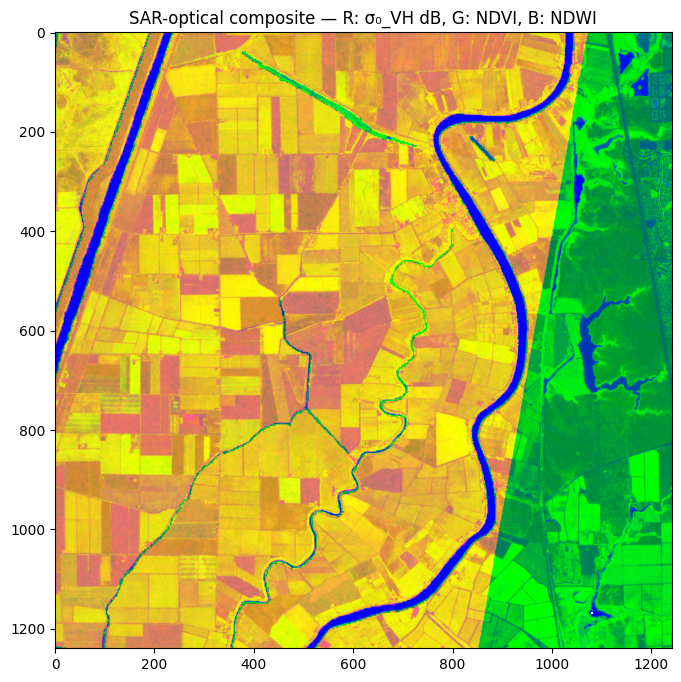

In [9]:
vh_name = find_band(p_coloc, 'Sigma0_VH_S1', 'Sigma0_VH')
ndvi_name = find_band(p_coloc, 'NDVI')
ndwi_name = find_band(p_coloc, 'NDWI')

vh = _read_band(p_coloc, vh_name)
vh_db = 10.0 * np.log10(np.maximum(vh, 1e-6))
ndvi = _read_band(p_coloc, ndvi_name)
ndwi = _read_band(p_coloc, ndwi_name)

# Independent stretches per channel
def stretch(arr, lo=2, hi=98):
    a, b = np.nanpercentile(arr, [lo, hi])
    return np.clip((arr - a) / (b - a + 1e-9), 0, 1)

r = stretch(vh_db)
g = stretch(ndvi)
b = stretch(ndwi)
rgb = np.stack([r, g, b], axis=-1)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(rgb)
ax.set_title('SAR-optical composite — R: σ₀_VH dB, G: NDVI, B: NDWI')
plt.show()

##### ***A simple thematic application: "wet vegetation" mask:***

Wet vegetation = high NDVI **and** moderately high backscatter — the SAR sees structure, the optical sees chlorophyll, and the two together can flag features like irrigated crops, mangroves, or flooded forest that neither sensor on its own would identify.

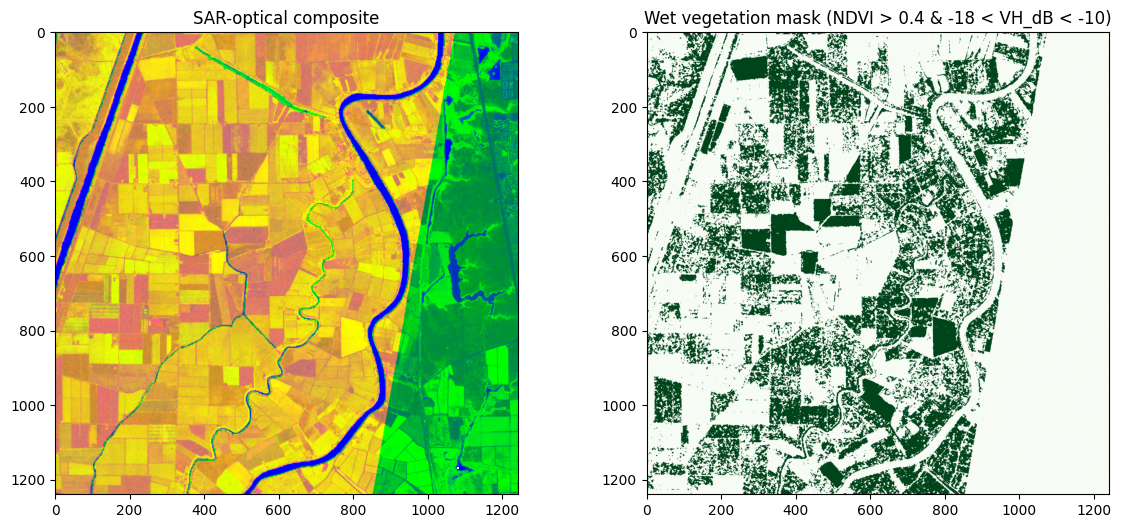

In [10]:
# Per-pixel rules — thresholds chosen for illustration; tune to your scene
wet_veg = (ndvi > 0.4) & (vh_db > -18) & (vh_db < -10)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].imshow(rgb)
axs[0].set_title('SAR-optical composite')
axs[1].imshow(wet_veg, cmap='Greens')
axs[1].set_title('Wet vegetation mask (NDVI > 0.4 & -18 < VH_dB < -10)')
plt.show()

p_coloc.dispose()

---

### ***Summary***

What have we learnt in this notebook?

- The standard SAR-optical fusion workflow is: preprocess each sensor independently into a terrain-corrected map-projected product, then `Collocate` them onto a shared grid.
- Picking **S2 as the master** keeps the result in S2's well-defined per-scene UTM grid and 10 m spacing — convenient for downstream tools.
- `Collocate`'s `slaveComponentPattern` lets you rename incoming bands to avoid collisions and to make later `BandMaths` expressions unambiguous.
- A simple **R = σ₀_VH dB / G = NDVI / B = NDWI** RGB composite is a surprisingly informative quick-look for any agriculture, wetland or urban-edge scene.
- Real applications combine these channels through thresholds, classifiers or decision rules — we showed the simplest case: a per-pixel rule for "wet vegetation".